In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind
import pymc as pm
import arviz as az
from pathlib import Path

In [32]:
data_path = Path("/home/robbin/Downloads/DBDA2Eprograms")
file_path = data_path / "TwoGroupIQ.csv"

df = pd.read_csv(file_path, header=0)
df["Group"] = pd.Categorical(df["Group"], categories=["Placebo", "Smart Drug"], ordered=True)
df.head()

,Score,Group
0,102,Smart Drug
1,107,Smart Drug
2,92,Smart Drug
3,101,Smart Drug
4,110,Smart Drug


In [33]:
tstat, pvalue, _ = ttest_ind(df[df["Group"]=="Placebo"]["Score"].values, df[df["Group"]=="Smart Drug"]["Score"].values, usevar="pooled")
print(f"t-statistic: {tstat:.4f}")
print(f"p-value: {pvalue:.4f}")

t-statistic: -1.9249
p-value: 0.0567


In [34]:
group_ids, group_labels = df["Group"].cat.codes.values, df["Group"].cat.categories.values
coords = {"group": group_labels}
with pm.Model(coords=coords) as model:
    # Priors
    mu = pm.Normal("mu", mu=df["Score"].mean(), sigma=df["Score"].std() * 100, dims="group")
    sigma = pm.Uniform("sigma", lower=df["Score"].std() / 1000, upper=df["Score"].std() * 1000, dims="group")
    nu_minus_one = pm.Exponential("nu_minus_one", lam=1/30)
    nu = pm.Deterministic("nu", nu_minus_one + 1)  # Ensure nu > 1 for finite variance

    # Likelihood
    y = pm.StudentT("y", mu=mu[group_ids], sigma=sigma[group_ids], nu=nu, observed=df["Score"].values)

    # Inference
    trace = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, nu_minus_one]
/home/robbin/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/robbin/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

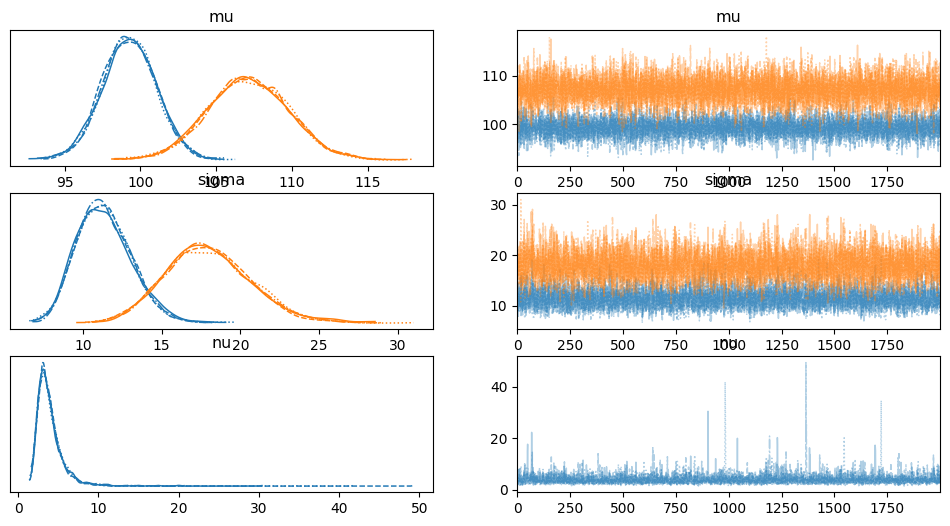

In [35]:
az.plot_trace(trace, var_names=["mu", "sigma", "nu"])

In [36]:
trace.posterior["mu"].sel(group="Smart Drug") - trace.posterior["mu"].sel(group="Placebo")

<xarray.DataArray 'mu' (chain: 4, draw: 2000)> Size: 64kB
array([[ 5.63145435, 10.63207697,  2.46103658, ...,  2.23155884,
         9.79320003,  8.35859506],
       [ 2.4351192 ,  7.67279606,  9.09100085, ...,  2.27126527,
         4.66260359,  4.98267341],
       [ 8.33920359,  7.43399963,  9.51972971, ...,  5.0902738 ,
         4.6960812 , 10.85593257],
       [13.47708382,  8.00642421,  5.45495377, ..., 11.26178113,
         4.99942961,  7.92230342]], shape=(4, 2000))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999